# UPI transactions trend analysis

## Overview
This project is an analysis of 10 years of UPI (Unified Payments Interface) transaction data collected from NPCI's (National Payments Corporation of India) public portal. Python is used for data cleaning, feature engineering, and exploratory data analysis. The goal of this project is to understand the growth of India's own digital payment system by transaction volume and value.

### Data Source
NPCI UPI Product Statistics: [ncpi.org.in](https://www.npci.org.in/product/upi/product-statistics)  
Multiple .xlsx files, one per year, containing monthly data from 2016-2026

### Columns in raw data
|Column Name|Description|
|-----------|-----------|
|`Month`|Month and year (e.g., April-2026)|
|`No. of Banks live on UPI`|No. of banks using UPI network|
|`Volume (In Mn.)`|No. of UPI transactions (Millions)|
|`Value (In Cr.)`|Total value of transactions (Crore INR)|

### Purpose of this notebook
1. Loading and appending all yearly excel files into a single dataframe.
2. Cleaning and standardizing column names and data formats.
3. Creating KPI columns like average transaction value, MoM and YoY growth, financial year labels.
4. Exploring trends in the data through charts.
5. Exporting clean excel file for Power BI analysis.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import glob

## Data Loading

In [2]:
files = glob.glob('../data/raw/UPI-data/*.xlsx')

df_raw = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)

print(df_raw.head())
print(f'Shape: {df_raw.shape}\n')
df = df_raw.copy()

           Month  No. of Banks live on UPI Volume (In Mn.) Value (In Cr.)
0     March-2017                        44            6.37        2425.14
1  February-2017                        44            4.38        1937.71
2   January-2017                        36            4.46        1696.22
3  December-2016                        35            1.99         707.93
4  November-2016                        30            0.29         100.46
Shape: (123, 4)



## Data Cleaning

In [3]:
df = df.drop_duplicates()
df = df.rename(
    columns={
        'Month':'period',
        'No. of Banks live on UPI':'banks_using_upi',
        'Volume (In Mn.)':'volume_mil',
        'Value (In Cr.)':'value_cr'
    }
)
df['period'] = pd.to_datetime(df['period'], format='%B-%Y')
df = df.sort_values('period').reset_index(drop=True)

In [4]:
df['volume_mil'] = pd.to_numeric(df['volume_mil'].astype(str).str.replace(',', ''))
df['value_cr'] = pd.to_numeric(df['value_cr'].astype(str).str.replace(',', ''))
print(df.head())
print(f'Shape: {df.shape}\n')
print(f'Null values:\n{df.isnull().sum()}')

      period  banks_using_upi  volume_mil  value_cr
0 2016-04-01               21        0.00      0.00
1 2016-05-01               21        0.00      0.00
2 2016-06-01               21        0.00      0.00
3 2016-07-01               21        0.09      0.38
4 2016-08-01               21        0.09      3.09
Shape: (123, 4)

Null values:
period             0
banks_using_upi    0
volume_mil         0
value_cr           0
dtype: int64


## Feature Engineering
`month_num` is added for sorting `month_name` chronologically instead of alphabetically in Power BI.  
  
`events` dataframe is created for overlaying key events to the volume chart to explain points of change. 

In [5]:
df['year'] = df['period'].dt.year
df['month_num'] = df['period'].dt.month
df['month_name'] = df['period'].dt.strftime('%b')
df['quarter'] = df['period'].dt.quarter
df['fy'] = df['period'].apply(lambda d: f'FY{d.year}-{str(d.year+1)[2:]}' if d.month >= 4 else f'FY{d.year-1}-{str(d.year)[2:]}')

In [6]:
df['avg_txn'] = ((df['value_cr']*1e7)/(df['volume_mil']*1e6)).round(2)
df['value_growth_mom'] = (df['value_cr'].pct_change()*100).round(2)
df['volume_growth_mom'] = (df['volume_mil'].pct_change()*100).round(2)
df['volume_growth_yoy'] = (df['volume_mil'].pct_change(12)*100).round(2)
df['cumulative_volume'] = df['volume_mil'].cumsum().round(2)
df['cumulative_value']  = df['value_cr'].cumsum().round(2)

In [7]:
# inf values because of volume = 0
# NaN values also because of volume = 0
# both replaced with 0 

df['value_growth_mom'] = df['value_growth_mom'].replace(np.inf, np.nan)
df['volume_growth_mom'] = df['volume_growth_mom'].replace(np.inf, np.nan)
df['volume_growth_yoy'] = df['volume_growth_yoy'].replace(np.inf, np.nan)

df[['avg_txn', 'volume_growth_mom', 'value_growth_mom', 'volume_growth_yoy']] = df[['avg_txn', 'volume_growth_mom', 'value_growth_mom', 'volume_growth_yoy']].fillna(0)

In [8]:
df.head()

,period,banks_using_upi,volume_mil,value_cr,year,month_num,month_name,quarter,fy,avg_txn,value_growth_mom,volume_growth_mom,volume_growth_yoy,cumulative_volume,cumulative_value
0,2016-04-01,21,0.00,0.00,2016,4,Apr,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
1,2016-05-01,21,0.00,0.00,2016,5,May,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
2,2016-06-01,21,0.00,0.00,2016,6,Jun,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
3,2016-07-01,21,0.09,0.38,2016,7,Jul,3,FY2016-17,42.22,0.00,0.0,0.0,0.09,0.38
4,2016-08-01,21,0.09,3.09,2016,8,Aug,3,FY2016-17,343.33,713.16,0.0,0.0,0.18,3.47


In [9]:
df_info = pd.DataFrame(
    {
        'data_type' : df.dtypes,
        'null_values' : df.isnull().sum(),
        'min' : df.min(numeric_only=True),
        'max' : df.max(numeric_only=True),
        'avg' : df.mean(numeric_only=True),
        'median': df.median(numeric_only=True)
    }
)

df_info.T

,avg_txn,banks_using_upi,cumulative_value,cumulative_volume,fy,month_name,month_num,period,quarter,value_cr,value_growth_mom,volume_growth_mom,volume_growth_yoy,volume_mil,year
data_type,float64,int64,float64,float64,str,str,int32,datetime64[us],int32,float64,float64,float64,float64,float64,int32
null_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
min,0.0,21.0,0.0,0.0,NaN,NaN,1.0,NaN,1.0,0.0,-26.8,-19.83,0.0,0.0,2016.0
max,4857.0,731.0,115828228.01,797770.06,NaN,NaN,12.0,NaN,4.0,2990424.21,956.31,586.21,76860.0,23201.93,2026.0
avg,1703.034309,307.227642,25856629.435203,164032.580325,NaN,NaN,6.463415,NaN,2.487805,941692.91065,27.632602,15.615366,1762.448049,6485.935447,2020.878049
median,1630.48,224.0,8213440.71,46354.49,NaN,NaN,6.0,NaN,2.0,504886.44,4.98,5.5,72.96,2731.68,2021.0


In [10]:
events_dict = {
    'date': ['2016-11-08', '2020-01-01','2023-08-31'],
    'event': ['Demonetisation', 'Zero MDR on UPI', 'UPI Crosses 10Bn/month']
}

events = pd.DataFrame(events_dict, columns=['date', 'event'])

events['date'] = pd.to_datetime(events['date'])
events

,date,event
0,2016-11-08,Demonetisation
1,2020-01-01,Zero MDR on UPI
2,2023-08-31,UPI Crosses 10Bn/month


In [11]:
df.head()

,period,banks_using_upi,volume_mil,value_cr,year,month_num,month_name,quarter,fy,avg_txn,value_growth_mom,volume_growth_mom,volume_growth_yoy,cumulative_volume,cumulative_value
0,2016-04-01,21,0.00,0.00,2016,4,Apr,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
1,2016-05-01,21,0.00,0.00,2016,5,May,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
2,2016-06-01,21,0.00,0.00,2016,6,Jun,2,FY2016-17,0.00,0.00,0.0,0.0,0.00,0.00
3,2016-07-01,21,0.09,0.38,2016,7,Jul,3,FY2016-17,42.22,0.00,0.0,0.0,0.09,0.38
4,2016-08-01,21,0.09,3.09,2016,8,Aug,3,FY2016-17,343.33,713.16,0.0,0.0,0.18,3.47


## Visualizations
Charts for Average transaction value, Average monthly volume, and MoM growth % start from 2018, as figures before 2018 are skewed due to low transaction volumes.
 

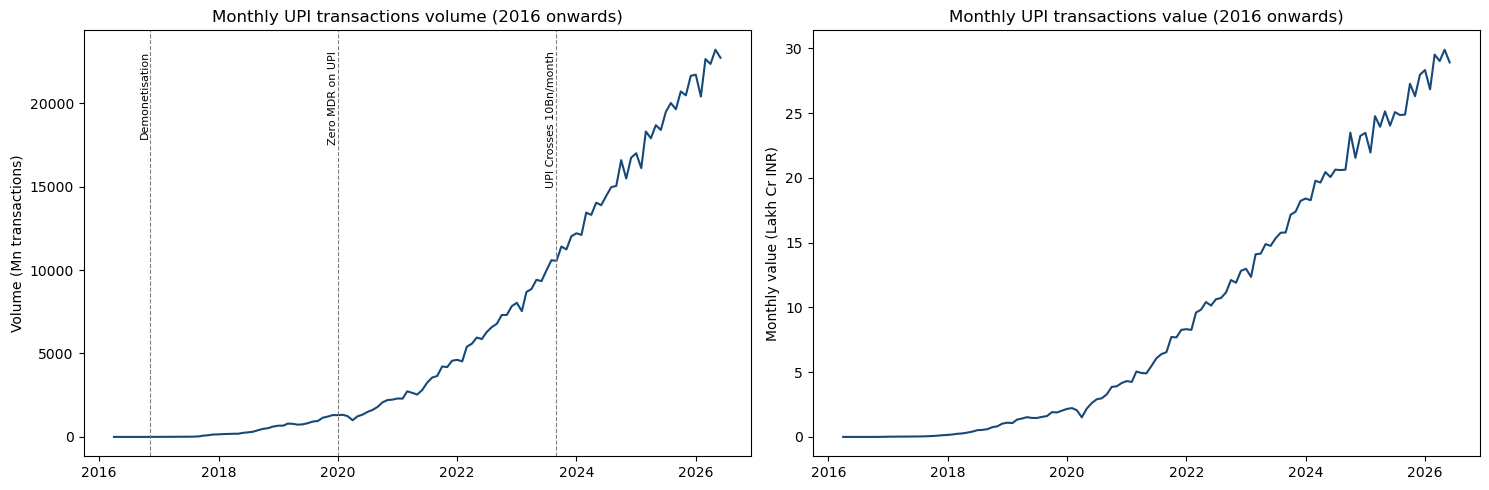

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(df['period'], df['volume_mil'], color='#174978')
axs[0].set_title('Monthly UPI transactions volume (2016 onwards)')
axs[0].set_ylabel('Volume (Mn transactions)')
for index, row in events.iterrows():
    axs[0].axvline(row['date'], color='gray', linestyle='--', lw=0.8)
    axs[0].text(row['date'], axs[0].get_ylim()[1]*0.95, row['event'], rotation=90, fontsize=8, va='top', ha='right')

axs[1].plot(df['period'], df['value_cr']/1e5, color='#174978')
axs[1].set_title('Monthly UPI transactions value (2016 onwards)')
axs[1].set_ylabel('Monthly value (Lakh Cr INR)')

plt.tight_layout()
plt.show()

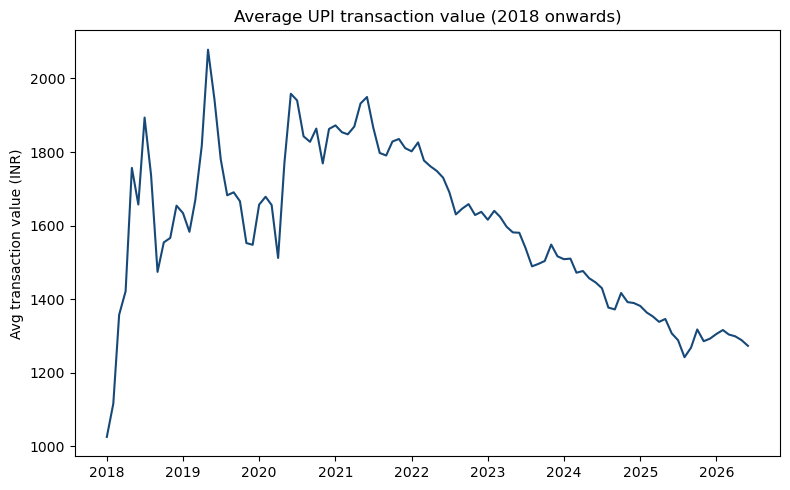

In [13]:
df_chart = df[df['period'] >= '2018-01-01']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_chart['period'], df_chart['avg_txn'], color='#174978')
ax.set_title('Average UPI transaction value (2018 onwards)')
ax.set_ylabel('Avg transaction value (INR)')
plt.tight_layout()
plt.show()

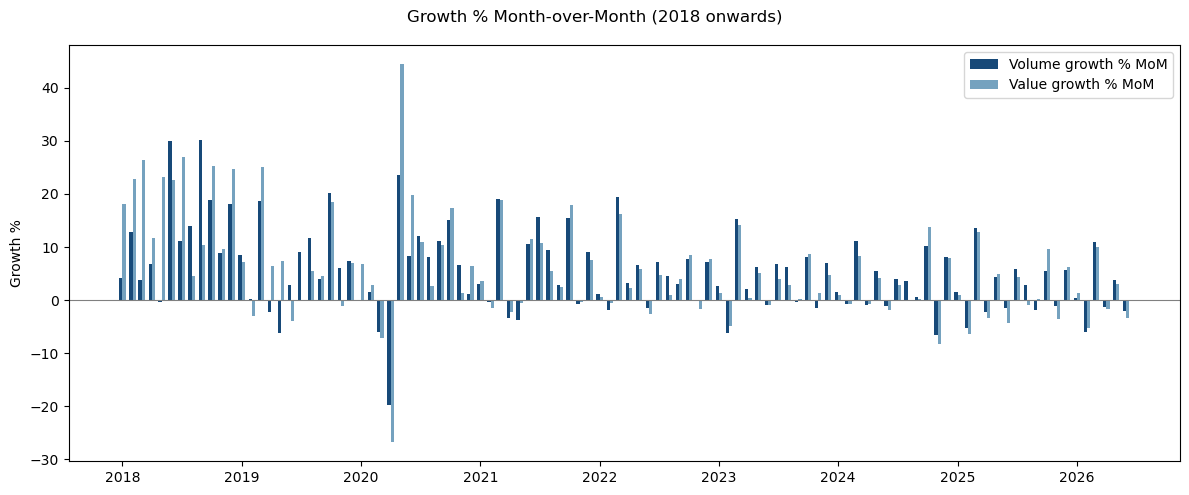

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Growth % Month-over-Month (2018 onwards)')

width = 10

ax.bar(df_chart['period'] - pd.Timedelta(days=width/2), df_chart['volume_growth_mom'], width=width, label='Volume growth % MoM', color='#174978')
ax.bar(df_chart['period'] + pd.Timedelta(days=width/2), df_chart['value_growth_mom'], width=width, label='Value growth % MoM', color='#75a2bf')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('Growth %')
ax.legend()

plt.tight_layout()
plt.show()

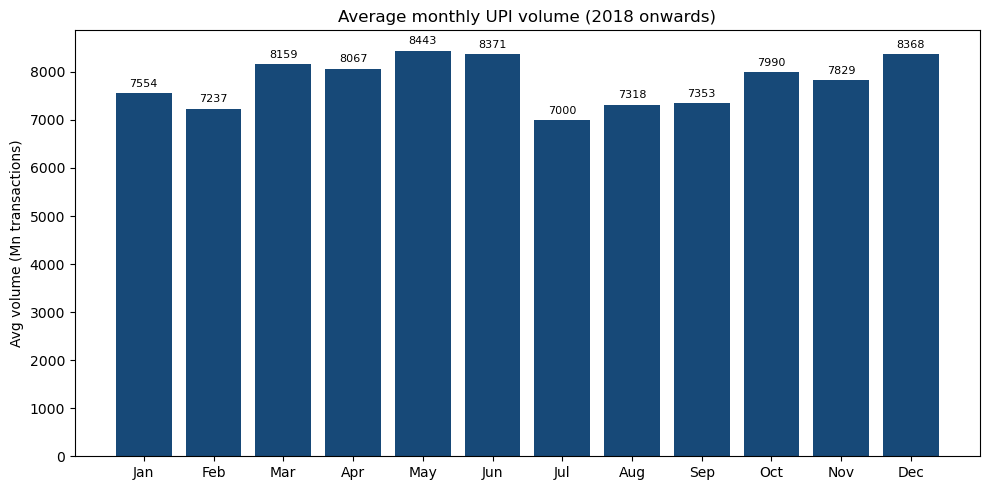

In [15]:
seasonal = df_chart.groupby(['month_num', 'month_name']).agg(avg_volume=('volume_mil', 'mean')).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seasonal['month_name'], seasonal['avg_volume'], color='#174978')
ax.bar_label(bars, fmt='%.0f', fontsize=8, padding=3)
ax.set_title('Average monthly UPI volume (2018 onwards)')
ax.set_ylabel('Avg volume (Mn transactions)')
plt.tight_layout()
plt.show()

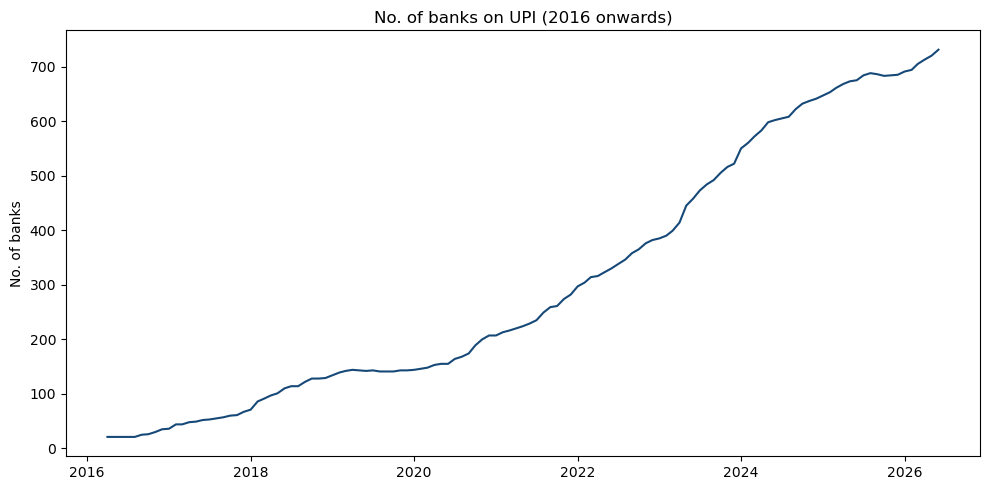

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['period'], df['banks_using_upi'], color='#174978')
ax.set_title('No. of banks on UPI (2016 onwards)')
ax.set_ylabel('No. of banks')
plt.tight_layout()
plt.show()

### Observations and key insights
1. Volume and value had exponential growth, from near zero in 2016 to more than 23,000+ Mn transactions per month in 2026. Volume and value grew together following the same trend.
  
2. Average transaction value declined from around ₹1800 (2018) to about ₹1300 (2026) even when total transaction value was increasing. This shows the use of UPI increased for smaller everyday payments.
  
3. MoM growth is initially (2018-2019) highly volatile, and later (2022 onwards) settles into consistent growth. There was negative growth in early 2020 due to COVID-19.
  
4. Average monthly transaction volume peaks are seen around March–May and October–November which probably correspond to FY-end payments in March, wedding season, school/college admissions, and summer travel in April-May, and festive (Diwali) spending in October-November.
  
5. The number of banks supporting UPI increased from 21 in 2016 to more than 700 in 2026.

## Exporting Excel file for Power BI 

In [17]:
with pd.ExcelWriter("../data/processed/upi_clean.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Monthly_UPI", index=False)
    events.to_excel(writer, sheet_name="Events", index=False)

print("Exported: upi_clean.xlsx")

Exported: upi_clean.xlsx
